# Book Recommendation System

## 1. Data Preprocessing and Exploratory Data Analysis

This notebook loads the book and rating datasets, performs basic data cleaning, explores important dataset characteristics, and exports the merged book-rating data for the recommendation notebooks.

## 2. Import Libraries

The project uses pandas and NumPy for data manipulation, with Matplotlib and Seaborn available for exploratory visualizations.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

In [3]:
project_path = Path().resolve().parent
book_file_path = project_path / "Data" / "Books.csv"
rating_file_path = project_path / "Data" / "Ratings.csv"

## 3. Load Dataset

Load the books metadata and user ratings datasets from the local `Data` directory.

In [4]:
books = pd.read_csv(book_file_path, low_memory=False)

ratings = pd.read_csv(rating_file_path, low_memory=False)

## 4. Data Understanding

Inspect the books dataset shape, sample records, column types, and missing values before cleaning.

In [5]:
books.shape

(271360, 8)

In [6]:
books.head(1)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...


In [7]:
books.tail(1)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
271359,0767409752,A Guided Tour of Rene Descartes' Meditations o...,Christopher Biffle,2000,McGraw-Hill Humanities/Social Sciences/Languages,http://images.amazon.com/images/P/0767409752.0...,http://images.amazon.com/images/P/0767409752.0...,http://images.amazon.com/images/P/0767409752.0...


In [8]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   ISBN                 271360 non-null  str  
 1   Book-Title           271360 non-null  str  
 2   Book-Author          271358 non-null  str  
 3   Year-Of-Publication  271360 non-null  str  
 4   Publisher            271358 non-null  str  
 5   Image-URL-S          271360 non-null  str  
 6   Image-URL-M          271360 non-null  str  
 7   Image-URL-L          271357 non-null  str  
dtypes: str(8)
memory usage: 16.6 MB


## 5. Data Cleaning and Preprocessing

Correct known malformed publication-year records, remove missing rows, convert publication years to integers, and keep books published before 2026.

In [9]:
# Correct known malformed rows where publisher/author values appear in the publication-year column.
books["Year-Of-Publication"] = books["Year-Of-Publication"].replace({"DK Publishing Inc": 2000, "Gallimard": 2003, "0": np.nan})
books["Book-Author"] = books["Book-Author"].replace({"2000": "DK Publishing Inc", "2003": "Gallimard"})

In [10]:
books = books.dropna()
books["Year-Of-Publication"] = books["Year-Of-Publication"].astype("int")

In [11]:
books.info()

<class 'pandas.DataFrame'>
Index: 266735 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   ISBN                 266735 non-null  str  
 1   Book-Title           266735 non-null  str  
 2   Book-Author          266735 non-null  str  
 3   Year-Of-Publication  266735 non-null  int64
 4   Publisher            266735 non-null  str  
 5   Image-URL-S          266735 non-null  str  
 6   Image-URL-M          266735 non-null  str  
 7   Image-URL-L          266735 non-null  str  
dtypes: int64(1), str(7)
memory usage: 18.3 MB


In [12]:
books["Year-Of-Publication"].describe()

count    266735.000000
mean       1993.689688
std           8.325839
min        1376.000000
25%        1989.000000
50%        1996.000000
75%        2000.000000
max        2050.000000
Name: Year-Of-Publication, dtype: float64

In [13]:
# Keep publication years within the project timeline used in the original analysis.
books = books[books["Year-Of-Publication"] < 2026]

In [14]:
books[["ISBN", "Book-Title"]].duplicated().sum()

np.int64(0)

## 6. Exploratory Data Analysis

Explore publication-year distribution, author coverage, publisher coverage, and the most frequent authors and publishers.

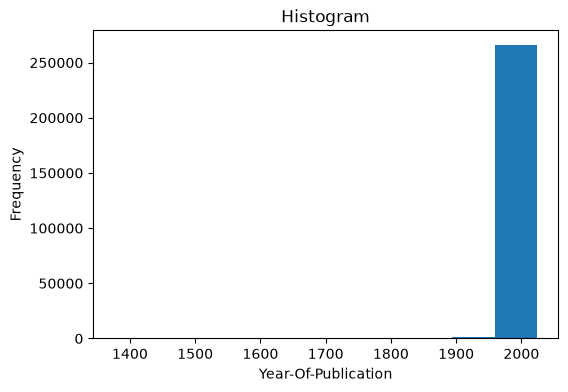

In [15]:
books["Year-Of-Publication"].plot(kind="hist", figsize=(6, 4), xlabel="Year-Of-Publication")
plt.title("Histogram")
plt.show()

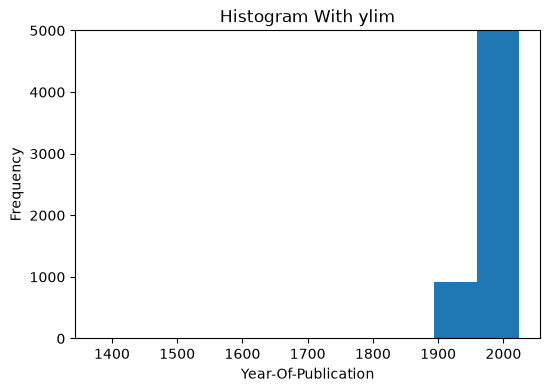

In [16]:
books["Year-Of-Publication"].plot(kind="hist", figsize=(6, 4), xlabel="Year-Of-Publication", ylim=(0, 5000))
plt.title("Histogram With ylim")
plt.show()

<Axes: ylabel='Density'>

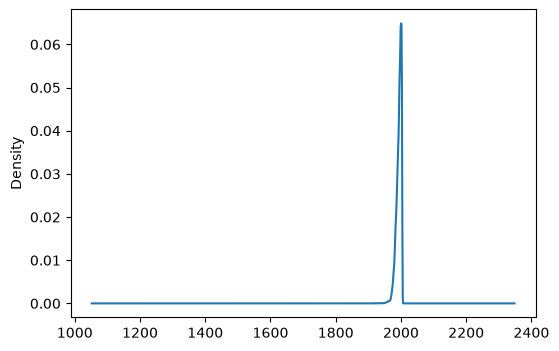

In [17]:
books["Year-Of-Publication"].plot(kind="kde", figsize=(6, 4), xlabel="Year-Of-Publication")

<Axes: >

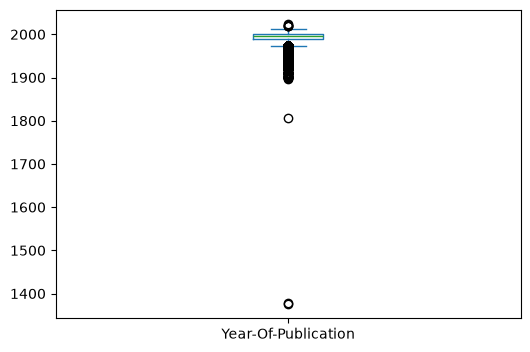

In [18]:
books["Year-Of-Publication"].plot(kind="box", figsize=(6, 4))

In [19]:
len(books["Book-Author"].unique())

100665

In [20]:
len(books["Publisher"].unique())

16393

In [21]:
top_25_authors = books["Book-Author"].value_counts().head(25)

<Axes: xlabel='Book-Author', ylabel='Number of Books Written by Author'>

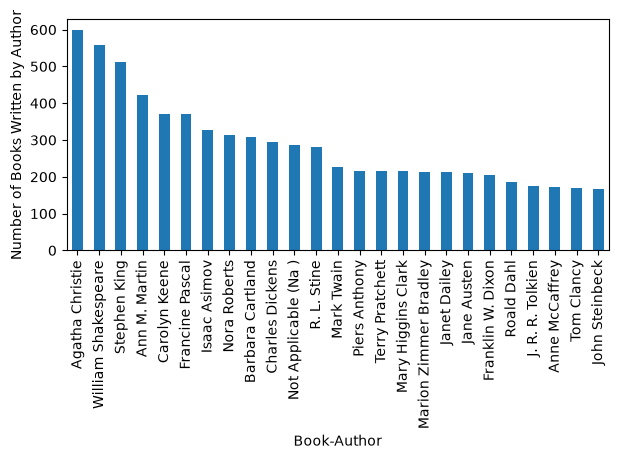

In [22]:
top_25_authors.plot(kind="bar", x="Book-Author", figsize=(7, 3), ylabel="Number of Books Written by Author")

In [23]:
top_25_publishers = books["Publisher"].value_counts().head(25)

<Axes: xlabel='Publisher', ylabel='Number of Books Published'>

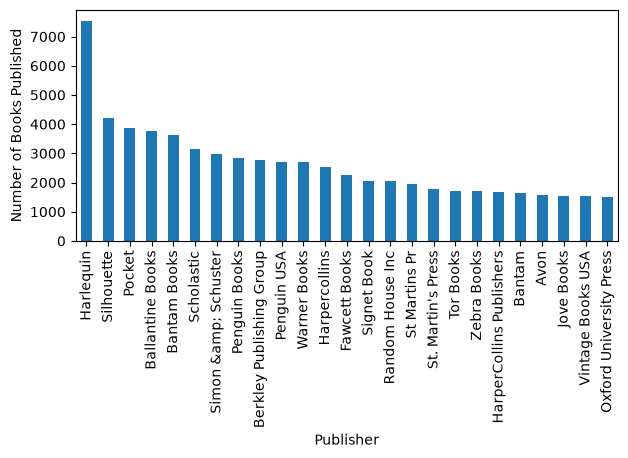

In [24]:
top_25_publishers.plot(kind="bar", x="Publisher", y="count", figsize=(7, 3), ylabel="Number of Books Published")

## 7. Ratings Dataset

Inspect user-book rating records, rating distribution, and the number of unique users and rating values.

In [25]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [26]:
ratings.tail()

,User-ID,ISBN,Book-Rating
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10
1149779,276723,05162443314,8


In [27]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   User-ID      1149780 non-null  int64
 1   ISBN         1149780 non-null  str  
 2   Book-Rating  1149780 non-null  int64
dtypes: int64(2), str(1)
memory usage: 26.3 MB


In [28]:
ratings["Book-Rating"].describe()

count    1.149780e+06
mean     2.866950e+00
std      3.854184e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      7.000000e+00
max      1.000000e+01
Name: Book-Rating, dtype: float64

In [29]:
ratings.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [30]:
ratings["User-ID"].nunique()

105283

In [31]:
ratings["Book-Rating"].nunique()

11

In [32]:
ratings["Book-Rating"].value_counts()

Book-Rating
0     716109
8     103736
10     78610
7      76457
9      67541
5      50974
6      36924
4       8904
3       5996
2       2759
1       1770
Name: count, dtype: int64

## 8. Merge Books and Ratings

Merge book metadata with user ratings on `ISBN` so later recommendation notebooks can work from a single book-rating dataset.

In [33]:
books_with_ratings = books.merge(ratings, on="ISBN")

In [34]:
books_with_ratings.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,User-ID,Book-Rating
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,2,0
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,8,5
2,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,11400,0
3,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,11676,8
4,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,41385,0


In [35]:
books_with_ratings.shape

(1017066, 10)

In [36]:
books_with_ratings.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
User-ID                0
Book-Rating            0
dtype: int64

In [37]:
books_with_ratings.duplicated().sum()

np.int64(0)

In [38]:
book_rating_distribution = books_with_ratings["Book-Rating"].value_counts()

<Axes: xlabel='Books Rating', ylabel='Frequency'>

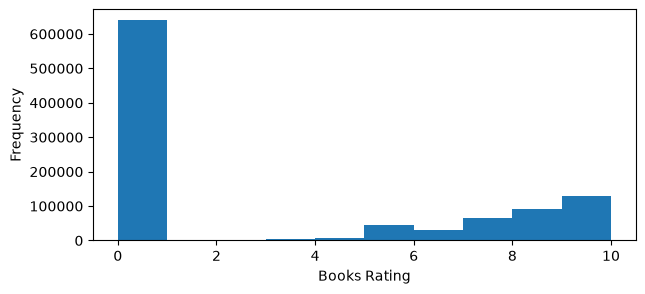

In [39]:
books_with_ratings["Book-Rating"].plot(kind="hist", figsize=(7, 3), xlabel="Books Rating")

In [40]:
books_with_ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017066 entries, 0 to 1017065
Data columns (total 10 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   ISBN                 1017066 non-null  str  
 1   Book-Title           1017066 non-null  str  
 2   Book-Author          1017066 non-null  str  
 3   Year-Of-Publication  1017066 non-null  int64
 4   Publisher            1017066 non-null  str  
 5   Image-URL-S          1017066 non-null  str  
 6   Image-URL-M          1017066 non-null  str  
 7   Image-URL-L          1017066 non-null  str  
 8   User-ID              1017066 non-null  int64
 9   Book-Rating          1017066 non-null  int64
dtypes: int64(3), str(7)
memory usage: 77.6 MB


## 9. Popular Books Summary

Calculate each book's rating count and average rating, then list highly rated books that have more than 250 ratings.

In [41]:
book_rating_count_df = books_with_ratings.groupby("Book-Title").count()["Book-Rating"].reset_index()
book_rating_count_df.rename(columns={"Book-Rating": "Num_Rating"}, inplace=True)

In [42]:
book_average_rating_df = books_with_ratings.groupby("Book-Title")["Book-Rating"].mean().reset_index()
book_average_rating_df.rename(columns={"Book-Rating": "Avg_Rating"}, inplace=True)

In [43]:
book_rating_summary_df = book_rating_count_df.merge(book_average_rating_df, on="Book-Title")

In [44]:
book_rating_summary_df.head()

,Book-Title,Num_Rating,Avg_Rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.25
1,Always Have Popsicles,1,0.00
2,Apple Magic (The Collector's series),1,0.00
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.00
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.00


In [45]:
# The existing threshold keeps books with enough ratings for a more reliable popularity summary.
top_50_books = book_rating_summary_df[book_rating_summary_df["Num_Rating"] > 250].sort_values(by="Avg_Rating", ascending=False).head(50)

In [46]:
top_50_books = top_50_books.merge(books, on="Book-Title").drop_duplicates("Book-Title")

In [47]:
top_50_books.head(1)

,Book-Title,Num_Rating,Avg_Rating,ISBN,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804,0439136350,J. K. Rowling,1999,Scholastic,http://images.amazon.com/images/P/0439136350.0...,http://images.amazon.com/images/P/0439136350.0...,http://images.amazon.com/images/P/0439136350.0...


### Compress size

In [48]:
books_with_ratings.drop(["Image-URL-S","Image-URL-M"], axis=1, inplace=True)

In [49]:
books_with_ratings["Year-Of-Publication"] = books_with_ratings["Year-Of-Publication"].astype("int32")
books_with_ratings["User-ID"] = books_with_ratings["User-ID"].astype("int32")
books_with_ratings["Book-Rating"] = books_with_ratings["Book-Rating"].astype("int32")

In [50]:
books_with_ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017066 entries, 0 to 1017065
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   ISBN                 1017066 non-null  str  
 1   Book-Title           1017066 non-null  str  
 2   Book-Author          1017066 non-null  str  
 3   Year-Of-Publication  1017066 non-null  int32
 4   Publisher            1017066 non-null  str  
 5   Image-URL-L          1017066 non-null  str  
 6   User-ID              1017066 non-null  int32
 7   Book-Rating          1017066 non-null  int32
dtypes: int32(3), str(5)
memory usage: 50.4 MB


In [51]:
top_50_books.info()

<class 'pandas.DataFrame'>
Index: 50 entries, 0 to 190
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Book-Title           50 non-null     str    
 1   Num_Rating           50 non-null     int64  
 2   Avg_Rating           50 non-null     float64
 3   ISBN                 50 non-null     str    
 4   Book-Author          50 non-null     str    
 5   Year-Of-Publication  50 non-null     int64  
 6   Publisher            50 non-null     str    
 7   Image-URL-S          50 non-null     str    
 8   Image-URL-M          50 non-null     str    
 9   Image-URL-L          50 non-null     str    
dtypes: float64(1), int64(2), str(7)
memory usage: 4.3 KB


## 10. Export Prepared Dataset

Save the merged book-rating DataFrame for the collaborative filtering notebook.

In [52]:
books_with_rating_path = project_path / "Data" / "books_with_rating.pkl"

In [53]:
books_with_ratings.to_pickle(books_with_rating_path)

In [54]:
with open(project_path / "Data" / "Top_50_books.pkl","wb") as file:
    pickle.dump(top_50_books,file)